# Specimen 02 — Sentiment Analysis on Movie Reviews

Goal: your first NLP task. Text isn't numeric — learn to turn words into something a network can read, then train a classifier on top.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
import matplotlib.pyplot as plt

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', device)


Using device: mps


## 1. Load & inspect

`load_dataset('imdb')` from Hugging Face `datasets`. Check review length distribution and label balance.

25000 25000
10 2470 233.7872
Counter({0: 12500, 1: 12500})


Counter({0: 12500, 1: 12500})


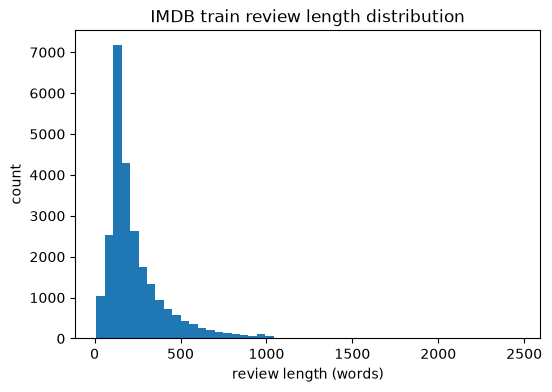

In [2]:
raw = load_dataset('stanfordnlp/imdb')
train_data = raw['train']
test_data = raw['test']

lengths = [len(t.split()) for t in train_data['text']]
print(len(train_data), len(test_data))
print(min(lengths), max(lengths), sum(lengths) / len(lengths))

from collections import Counter
print(Counter(train_data['label']))
print(Counter(test_data['label']))

plt.figure(figsize=(6, 4))
plt.hist(lengths, bins=50)
plt.xlabel('review length (words)')
plt.ylabel('count')
plt.title('IMDB train review length distribution')
plt.show()

## 2. Tokenize & build a vocabulary

Pick a max vocab size, decide how to handle out-of-vocab and padding tokens, pick a max sequence length.

In [3]:
import re
from collections import Counter

def tokenize(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r"[^a-z0-9']+", ' ', text)
    return text.split()

counter = Counter()
for text in train_data['text']:
    counter.update(tokenize(text))

max_vocab_size = 20000
most_common = counter.most_common(max_vocab_size - 2)

vocab = {'<pad>': 0, '<unk>': 1}
for word, _ in most_common:
    vocab[word] = len(vocab)

max_len = 200

def encode(text):
    tokens = tokenize(text)[:max_len]
    ids = [vocab.get(tok, vocab['<unk>']) for tok in tokens]
    ids = ids + [vocab['<pad>']] * (max_len - len(ids))
    return ids

print(len(vocab))
print(encode(train_data['text'][0])[:20])

20000
[10, 1605, 10, 241, 1992, 4173, 36, 58, 371, 1126, 84, 5, 29, 2, 7089, 12, 3383, 9, 51, 9]


## 3. Represent text numerically

An `nn.Embedding` layer — turn each review into a fixed-length integer sequence first.

In [4]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.inputs = torch.tensor([encode(t) for t in texts], dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.inputs[idx], self.labels[idx]

val_size = 2500
train_texts = train_data['text'][val_size:]
train_labels = train_data['label'][val_size:]
val_texts = train_data['text'][:val_size]
val_labels = train_data['label'][:val_size]

train_dataset = IMDBDataset(train_texts, train_labels)
val_dataset = IMDBDataset(val_texts, val_labels)
test_dataset = IMDBDataset(test_data['text'], test_data['label'])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

sample_inputs, sample_labels = next(iter(train_loader))
embedding_demo = nn.Embedding(len(vocab), 100, padding_idx=0)
sample_embedded = embedding_demo(sample_inputs)
print(sample_inputs.shape, sample_embedded.shape)

torch.Size([64, 200]) torch.Size([64, 200, 100])


## 4. Build a bag-of-embeddings model

Embedding → mean/max pooling → dense layers → sigmoid output. Cheaper than an RNN — good first step.

In [5]:
class BagOfEmbeddings(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=64, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.pad_idx = pad_idx

    def forward(self, x):
        mask = (x != self.pad_idx).unsqueeze(-1).float()
        embedded = self.embedding(x) * mask
        summed = embedded.sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1)
        pooled = summed / lengths
        hidden = torch.relu(self.fc1(pooled))
        return self.fc2(hidden).squeeze(-1)

boe_model = BagOfEmbeddings(len(vocab)).to(device)
print(boe_model)

BagOfEmbeddings(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (fc1): Linear(in_features=100, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


## 5. Train with a real loop

Mirror specimen 01's hand-written loop. Track loss/accuracy curves.

Epoch 1/6  train_loss=0.5460  val_loss=0.4922  val_acc=0.7584


Epoch 2/6  train_loss=0.3265  val_loss=0.4419  val_acc=0.7956


Epoch 3/6  train_loss=0.2480  val_loss=0.4573  val_acc=0.8020


Epoch 4/6  train_loss=0.1961  val_loss=0.5593  val_acc=0.7784


Epoch 5/6  train_loss=0.1561  val_loss=0.5464  val_acc=0.7992


Epoch 6/6  train_loss=0.1229  val_loss=0.6569  val_acc=0.7852
Bag-of-embeddings training time: 21.6s


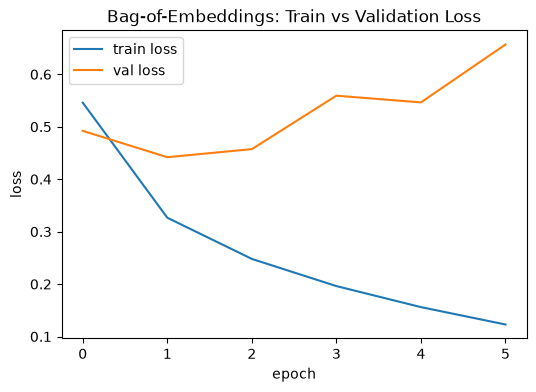

In [6]:
import time

def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                correct += (preds == labels).sum().item()

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

    return history

boe_start = time.time()
boe_history = train_model(boe_model, train_loader, val_loader, epochs=6)
boe_train_time = time.time() - boe_start
print(f'Bag-of-embeddings training time: {boe_train_time:.1f}s')

plt.figure(figsize=(6, 4))
plt.plot(boe_history['train_loss'], label='train loss')
plt.plot(boe_history['val_loss'], label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Bag-of-Embeddings: Train vs Validation Loss')
plt.legend()
plt.show()

## 6. Try a recurrent upgrade

Swap in an LSTM or GRU (or a 1D conv over the sequence). Does it beat the pooled-embedding baseline enough to justify the extra training time?

In [7]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.pad_idx = pad_idx

    def forward(self, x):
        lengths = (x != self.pad_idx).sum(dim=1).clamp(min=1).cpu()
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(embedded, lengths, batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        return self.fc(hidden[-1]).squeeze(-1)

lstm_model = LSTMClassifier(len(vocab)).to(device)

lstm_start = time.time()
lstm_history = train_model(lstm_model, train_loader, val_loader, epochs=4)
lstm_train_time = time.time() - lstm_start
print(f'LSTM training time: {lstm_train_time:.1f}s')

print(f"Bag-of-embeddings best val acc: {max(boe_history['val_acc']):.4f} in {boe_train_time:.1f}s")
print(f"LSTM best val acc: {max(lstm_history['val_acc']):.4f} in {lstm_train_time:.1f}s")

Epoch 1/4  train_loss=0.6579  val_loss=0.6798  val_acc=0.5656


Epoch 2/4  train_loss=0.5851  val_loss=0.7069  val_acc=0.5332


Epoch 3/4  train_loss=0.4624  val_loss=0.6194  val_acc=0.7632


Epoch 4/4  train_loss=0.3718  val_loss=0.5021  val_acc=0.7932
LSTM training time: 489.7s
Bag-of-embeddings best val acc: 0.8020 in 21.6s
LSTM best val acc: 0.7932 in 489.7s


## 7. Inspect mistakes

Pull a handful of reviews the model gets wrong. Sarcastic? Mixed sentiment? Just short and ambiguous?

In [8]:
lstm_model.eval()
all_preds = []
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = lstm_model(inputs)
        probs = torch.sigmoid(outputs).cpu()
        preds = (probs >= 0.5).float()
        all_preds.append(preds)
        all_probs.append(probs)
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_probs = torch.cat(all_probs).numpy()
all_labels = torch.cat(all_labels).numpy()

mismatch_idx = [i for i in range(len(all_labels)) if all_preds[i] != all_labels[i]][:8]
for i in mismatch_idx:
    print(f'true={int(all_labels[i])} pred={int(all_preds[i])} prob={all_probs[i]:.3f}')
    print(test_data['text'][i][:300])
    print('---')

true=0 pred=1 prob=0.904
Blind Date (Columbia Pictures, 1934), was a decent film, but I have a few issues with this film. First of all, I don't fault the actors in this film at all, but more or less, I have a problem with the script. Also, I understand that this film was made in the 1930's and people were looking to escape 
---
true=0 pred=1 prob=0.519
I saw the Mogul Video VHS of this. That's another one of those old 1980s distributors whose catalog I wish I had!<br /><br />This movie was pretty poor. Though retitled "Don't Look in the Attic," the main admonition that is repeated in this is "Don't go to the villa." Just getting on the grounds of 
---
true=0 pred=1 prob=0.503
Ben, (Rupert Grint), is a deeply unhappy adolescent, the son of his unhappily married parents. His father, (Nicholas Farrell), is a vicar and his mother, (Laura Linney), is ... well, let's just say she's a somewhat hypocritical soldier in Jesus' army. It's only when he takes a summer job as an assis
---
true=0 pre

## 8. Final evaluation

Accuracy + precision/recall on the held-out test set, once.

In [9]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

test_acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')

print(f'LSTM test accuracy: {test_acc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1: {f1:.4f}')

LSTM test accuracy: 0.8108
Precision: 0.8181
Recall: 0.7994
F1: 0.8086
